<a href="https://colab.research.google.com/github/ec-yua1122/DBA_COURSEWORK_A2/blob/main/SQL_R_Analytics_dba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility — SQL and R Analytics
## SQL within R, R Analytics and Visualization

This notebook provides a comprehensive analysis of Northstar's operational data, covering delivery performance, vehicle maintenance, customer complaints, and profitability across various service types and hubs. It utilizes SQL queries for data extraction and R for statistical analysis and visualizations to derive key insights and identify areas for improvement.

In [ ]:
#Uploading Files from the dataset
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


In [ ]:
#  SETUP BLOCK

install.packages(c("sqldf", "dplyr", "ggplot2", "lubridate", "scales", "tidyr"))

library(sqldf)
library(dplyr)
library(ggplot2)
library(lubridate)
library(scales)
library(tidyr)

# Load all nine datasets
customers  <- read.csv("/content/customers.csv",  stringsAsFactors = FALSE)
orders     <- read.csv("/content/orders.csv",     stringsAsFactors = FALSE)
deliveries <- read.csv("/content/deliveries.csv", stringsAsFactors = FALSE)
drivers    <- read.csv("/content/drivers.csv",    stringsAsFactors = FALSE)
hubs       <- read.csv("/content/hubs.csv",       stringsAsFactors = FALSE)
vehicles   <- read.csv("/content/vehicles.csv",   stringsAsFactors = FALSE)
complaints <- read.csv("/content/complaints.csv", stringsAsFactors = FALSE)
incidents  <- read.csv("/content/incidents.csv",  stringsAsFactors = FALSE)
app_events <- read.csv("/content/app_events.csv", stringsAsFactors = FALSE)

# Data Quality Fix 1: Normalise inconsistent zone names
# The dataset contains "north", "NORTH", and "North" — all mean the same zone
# This inconsistency would cause GROUP BY queries to treat them as separate groups
orders$pickup_zone      <- toupper(trimws(orders$pickup_zone))
orders$dropoff_zone     <- toupper(trimws(orders$dropoff_zone))
app_events$zone_context <- toupper(trimws(app_events$zone_context))

# Data Quality Audit: Document missing values
cat("=== MISSING VALUE AUDIT ===\n")
cat("deliveries$delivery_completed_at:      ", sum(is.na(deliveries$delivery_completed_at)), "missing\n")
cat("deliveries$customer_rating:            ", sum(is.na(deliveries$customer_rating_post_delivery)), "missing\n")
cat("vehicles$battery_health_pct:           ", sum(is.na(vehicles$battery_health_pct)), "missing\n")
cat("drivers$training_score:                ", sum(is.na(drivers$training_score)), "missing\n")

# Summary counts
cat("\n=== DATASET ROW COUNTS ===\n")
cat("customers=", nrow(customers), "| orders=", nrow(orders),
    "| deliveries=", nrow(deliveries), "| complaints=", nrow(complaints),
    "| incidents=", nrow(incidents), "\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




=== MISSING VALUE AUDIT ===
deliveries$delivery_completed_at:       0 missing
deliveries$customer_rating:             14 missing
vehicles$battery_health_pct:            4 missing
drivers$training_score:                 7 missing

=== DATASET ROW COUNTS ===
customers= 650 | orders= 1250 | deliveries= 950 | complaints= 320 | incidents= 280 


##SQL Queries: Data Extraction and Transformation

This section contains SQL queries designed to extract and transform raw operational data into structured datasets for subsequent R analysis. These queries focus on key areas such as hub performance, customer complaints, route override behavior, vehicle maintenance, and profitability, providing the foundational data required for in-depth insights and visualizations.

##Delivery Failure and Delay Rate by Hub
SQL Query to To evaluate hub-level performance by analysing delivery outcomes, customer complaints, customer satisfaction scores, and operational indicators such as route overrides

In [ ]:
# SQL Query 1: Delivery Failure and Delay Rate by Hub

hub_performance <- sqldf("
SELECT
    h.hub_name,
    COUNT(d.delivery_id) AS total_deliveries,
    AVG(d.customer_rating_post_delivery) AS avg_rating,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_deliveries,
    SUM(CASE WHEN d.delivery_status = 'OnTime' THEN 1 ELSE 0 END) AS ontime_deliveries,
    AVG(d.manual_route_override_count) AS avg_overrides
FROM deliveries d
JOIN hubs h ON d.hub_id = h.hub_id
GROUP BY h.hub_name
ORDER BY failed_deliveries DESC
")

# Display SQL output as table
View(hub_performance)

hub_name,total_deliveries,avg_rating,failed_deliveries,delayed_deliveries,ontime_deliveries,avg_overrides
<chr>,<int>,<dbl>,<int>,<int>,<int>,<dbl>
Midtown Relay,128,3.884560,26,22,80,1.1093750
Central Core,115,3.669558,23,25,67,0.9478261
North Exchange,136,3.840593,17,26,93,1.0294118
West Gate,127,3.915476,16,28,83,0.8740157
Airport Hub,104,3.882136,15,27,62,0.9134615
Riverside Hub,115,3.881858,14,25,76,1.0521739
East Dock,119,3.895862,11,23,85,0.8907563
South Link,106,3.950952,10,26,70,0.9150943


##Customer Complaints Linked to Service Failures
This query joins complaints, orders, and deliveries to produce an integrated view of complaints by service type and complaint category, exactly the cross-system linkage the CX director is calling for.

In [ ]:
# SQL Query 2: Complaints linked to orders and service type
complaint_analysis <- sqldf("
  SELECT
    o.service_type,
    c.complaint_type,
    c.severity,
    COUNT(c.complaint_id)                                        AS complaint_count,
    ROUND(AVG(c.resolution_days), 1)                             AS avg_resolution_days,
    ROUND(AVG(c.compensation_amount), 2)                         AS avg_compensation,
    ROUND(SUM(c.compensation_amount), 2)                         AS total_compensation,
    SUM(CASE WHEN c.status = 'Open'      THEN 1 ELSE 0 END)      AS still_open,
    SUM(CASE WHEN c.status = 'Escalated' THEN 1 ELSE 0 END)      AS escalated,,
    SUM(CASE WHEN c.status = 'AwaitingCustomer' THEN 1 ELSE 0 END)      AS AwaitingCustomer
  FROM complaints c
  JOIN orders o ON c.order_id = o.order_id
  GROUP BY o.service_type, c.complaint_type, c.severity
  ORDER BY complaint_count DESC
")
View(complaint_analysis)

service_type,complaint_type,severity,complaint_count,avg_resolution_days,avg_compensation,total_compensation,still_open,escalated
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>
Retail,Delay,Medium,20,7.0,20.33,366.01,2,2
Passenger,Delay,Medium,14,7.4,15.81,221.31,4,1
Retail,MissedPickup,Medium,14,6.0,18.17,254.33,2,2
Parcel,DriverBehaviour,Medium,12,5.5,15.93,191.21,0,1
Business,Delay,Medium,10,3.7,19.43,194.35,2,2
Passenger,AppIssue,Medium,9,4.4,11.73,93.83,1,1
Parcel,Delay,Medium,8,4.5,19.64,137.50,1,1
Retail,AppIssue,Medium,8,6.8,15.22,121.76,0,1
Retail,Delay,Low,8,6.1,5.13,41.08,2,0


In [ ]:
# SQL Query 3: System Mismatch Between Delivery Status and Customer Complaints

mismatch_data <- sqldf("
SELECT
    d.delivery_status,
    COUNT(d.delivery_id) AS total_deliveries,
    COUNT(c.complaint_id) AS total_complaints,
    CASE
        WHEN d.delivery_status = 'OnTime' THEN 'Completed (but issues exist)'
        ELSE 'Already flagged as issue'
    END AS system_view
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
LEFT JOIN complaints c ON o.order_id = c.order_id
GROUP BY d.delivery_status
")

View(mismatch_data)

delivery_status,total_deliveries,total_complaints,system_view
<chr>,<int>,<int>,<chr>
Delayed,205,48,Already flagged as issue
Failed,134,35,Already flagged as issue
OnTime,634,149,Completed (but issues exist)


##Route Override Behaviour and Its Operational Impact

This query joins deliveries, drivers, and hubs to examine whether route overrides cluster around specific hubs, driver types, or experience levels  helping management understand whether the problem is structural (bad routes) or behavioural (driver avoidance).

In [ ]:
# SQL Query 4 — Route Overrides by Hub, Driver Type, and Experience
override_analysis <- sqldf("
SELECT
    h.hub_name,
    h.zone,
    dr.employment_type,
    COUNT(d.delivery_id) AS total_deliveries,
    AVG(d.manual_route_override_count) AS avg_overrides,
    AVG(dr.years_experience) AS avg_experience,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries
FROM deliveries d
JOIN hubs h ON d.hub_id = h.hub_id
JOIN drivers dr ON d.driver_id = dr.driver_id
GROUP BY h.hub_name, h.zone, dr.employment_type
ORDER BY avg_overrides DESC
")

View(override_analysis)

hub_name,zone,employment_type,total_deliveries,avg_overrides,avg_experience,delayed_deliveries,failed_deliveries
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>
East Dock,East,Contract,14,1.5000000,9.357143,2,2
Midtown Relay,Central,FullTime,90,1.1888889,8.811111,15,17
North Exchange,North,FullTime,83,1.1325301,7.951807,16,13
Riverside Hub,Riverside,FullTime,65,1.0923077,7.923077,16,8
Midtown Relay,Central,PartTime,25,1.0800000,6.800000,6,4
Central Core,Central,PartTime,33,1.0606061,8.575758,2,8
South Link,South,FullTime,70,1.0142857,7.342857,17,6
Airport Hub,Airport,Contract,12,1.0000000,6.500000,4,2
Airport Hub,Airport,FullTime,62,1.0000000,7.903226,13,11


##Vehicle and Asset Maintenance - Late Detection Evidence
This query analyzes vehicle maintenance status against incident types and delivery outcomes, providing key insights into vehicle reliability and operational impact.

In [ ]:

# SQL Query 5: Vehicle maintenance status vs incident types and delivery outcomes
vehicle_maintenance_analysis <- sqldf("
SELECT
    v.vehicle_type,
    v.maintenance_status,

    AVG(v.battery_health_pct) AS avg_battery_health,
    COUNT(i.incident_id) AS total_incidents,
    SUM(CASE WHEN i.resolution_status = 'Escalated' THEN 1 ELSE 0 END) AS escalated_incidents,
    AVG(i.resolved_hours) AS avg_resolution_time,
    COUNT(d.delivery_id) AS total_deliveries,
    AVG(d.route_distance_km) AS avg_distance,
    AVG(d.customer_rating_post_delivery) AS avg_rating

FROM vehicles v
LEFT JOIN deliveries d ON v.vehicle_id = d.vehicle_id
LEFT JOIN incidents i ON d.delivery_id = i.delivery_id

GROUP BY v.vehicle_type, v.maintenance_status
ORDER BY total_incidents DESC
")
View(vehicle_maintenance_analysis)

vehicle_type,maintenance_status,avg_battery_health,total_incidents,escalated_incidents,avg_resolution_time,total_deliveries,avg_distance,avg_rating
<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>
EV,Active,83.07156,61,7,11.653571,218,15.07665,3.955787
CargoVan,Active,74.26917,40,2,12.710526,120,14.70333,3.919915
Hybrid,Active,73.51930,30,5,10.889655,133,13.52150,3.946667
Diesel,InRepair,75.10833,25,6,12.734783,60,11.63750,3.684333
Hybrid,InRepair,82.88684,23,3,10.385000,76,14.63447,3.756267
EV,Scheduled,82.94030,22,1,11.027273,67,13.07075,3.955152
CargoVan,InRepair,69.37042,19,4,14.336842,71,13.42141,3.472000
Diesel,Active,66.44699,19,3,10.194737,83,12.89904,4.007089
EV,InRepair,77.80000,17,2,13.941176,61,13.90131,3.648475


##Profitability: Revenue vs Operational Cost by Service Type
This query joins orders and deliveries to calculate a revenue-versus-cost ratio by service type and pickup zone, giving the finance director the cross-system view that currently does not exist.


In [ ]:
# SQL QUERY 6 — Gross Margin by Service Type and Pickup Zone

profitability <- sqldf("
  SELECT
    o.service_type,
    o.pickup_zone,
    COUNT(o.order_id)                                              AS order_count,
    ROUND(SUM(o.order_value), 2)                                   AS total_revenue,
    ROUND(SUM(d.fuel_or_charge_cost), 2)                           AS total_fuel_cost,
    ROUND(SUM(o.order_value) - SUM(d.fuel_or_charge_cost), 2)      AS gross_margin,
    ROUND(AVG(o.order_value), 2)                                   AS avg_order_value,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                           AS avg_fuel_cost,
    ROUND(
      100.0 * (SUM(o.order_value) - SUM(d.fuel_or_charge_cost))
      / NULLIF(SUM(o.order_value), 0), 1
    )                                                              AS margin_pct,
    ROUND(AVG(d.route_distance_km), 1)                             AS avg_route_km
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type, o.pickup_zone
  ORDER BY margin_pct ASC
")

View(profitability)

service_type,pickup_zone,order_count,total_revenue,total_fuel_cost,gross_margin,avg_order_value,avg_fuel_cost,margin_pct,avg_route_km
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Business,AIRPORT,13,1081.84,244.10,837.74,83.22,18.78,77.4,30.6
Medical,CTR,2,107.85,22.27,85.58,53.92,11.13,79.4,12.1
Retail,AIRPORT,29,2687.13,519.15,2167.98,92.66,17.90,80.7,28.5
Business,WEST,12,856.36,158.61,697.75,71.36,13.22,81.5,14.7
Passenger,CENTRAL,34,2497.80,431.74,2066.06,73.46,12.70,82.7,11.5
Medical,EAST,19,1428.19,245.51,1182.68,75.17,12.92,82.8,12.6
Medical,NORTH,18,1300.36,222.47,1077.89,72.24,12.36,82.9,11.1
Parcel,RIVERSIDE,28,2007.65,338.88,1668.77,71.70,12.10,83.1,13.4
Retail,CTR,22,1728.18,292.25,1435.93,78.55,13.28,83.1,12.5


##Operational Statistical Analysis (System Overview)
This section provides baseline key indicators used to understand overall system performance across delivery operations, vehicle condition, customer satisfaction, and complaints.



In [ ]:
# Summary of statistical analysis

cat("--- Delivery Performance ---\n")
delivery_pct <- prop.table(table(deliveries$delivery_status)) * 100
cat("OnTime: ", round(delivery_pct["OnTime"], 1), "%\n")
cat("Delayed:", round(delivery_pct["Delayed"], 1), "%\n")
cat("Failed: ", round(delivery_pct["Failed"], 1), "%\n")


cat("\n--- Route Overrides ---\n")
cat("Average overrides per delivery:", round(mean(deliveries$manual_route_override_count), 2), "\n")
cat("Deliveries with 3+ overrides:  ",
    sum(deliveries$manual_route_override_count >= 3), "of", nrow(deliveries), "\n")


cat("\n--- Vehicle Fleet Status ---\n")
cat("Vehicles Active:    ", sum(vehicles$maintenance_status == "Active"),   "\n")
cat("Vehicles InRepair:  ", sum(vehicles$maintenance_status == "InRepair"), "\n")
cat("Vehicles Scheduled: ", sum(vehicles$maintenance_status == "Scheduled"),"\n")
cat("Average battery health (Active vehicles):",
    round(mean(vehicles$battery_health_pct[vehicles$maintenance_status == "Active"],
               na.rm = TRUE), 1), "%\n")


cat("\n--- Complaint Backlog ---\n")
cat("Total complaints:      ", nrow(complaints), "\n")
cat("Open:                  ", sum(complaints$status == "Open"), "\n")
cat("Escalated:             ", sum(complaints$status == "Escalated"), "\n")
cat("AwaitingCustomer:      ", sum(complaints$status == "AwaitingCustomer"), "\n")
cat("Resolved:              ", sum(complaints$status == "Resolved"), "\n")
cat("Total unresolved:      ",
    sum(complaints$status %in% c("Open","Escalated","AwaitingCustomer")), "\n")
cat("Average compensation paid per complaint: £",
    round(mean(complaints$compensation_amount, na.rm = TRUE), 2), "\n")
cat("Total compensation paid: £",
    round(sum(complaints$compensation_amount, na.rm = TRUE), 2), "\n")


cat("\n--- Customer Satisfaction ---\n")
cat("Overall average customer rating:",
    round(mean(deliveries$customer_rating_post_delivery, na.rm = TRUE), 2), "/ 5.00\n")
cat("Deliveries rated below 3.0:",
    sum(deliveries$customer_rating_post_delivery < 3.0, na.rm = TRUE), "\n")

=== NORTHSTAR OPERATIONAL SUMMARY STATISTICS ===

--- Delivery Performance ---
OnTime:  64.8 %
Delayed: 21.3 %
Failed:  13.9 %

--- Route Overrides ---
Average overrides per delivery: 0.97 
Deliveries with 3+ overrides:   88 of 950 

--- Vehicle Fleet Status ---
Vehicles Active:     67 
Vehicles InRepair:   36 
Vehicles Scheduled:  17 
Average battery health (Active vehicles): 76.6 %

--- Complaint Backlog ---
Total complaints:    320 
Open:       56 
Escalated:  38 
Resolved:   186 
Average compensation paid per complaint: £ 20.26 
Total compensation paid: £ 6158.19 

--- Customer Satisfaction ---
Overall average customer rating: 3.86 / 5.00
Deliveries rated below 3.0: 156 


##R Analytics and Visualization

This section uses the data extracted and transformed by the SQL queries to perform in-depth statistical analysis and create visualizations. These analyses further explore hub performance, customer complaints, route override behaviors, vehicle maintenance, and profitability. The visualizations provide clear, graphical representations of key trends, distributions, and relationships, making complex data insights accessible for decision-making.

,hub_name,total_deliveries,avg_rating,failed_deliveries,delayed_deliveries,ontime_deliveries,avg_overrides,failure_rate,delay_rate
,<chr>,<int>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,Midtown Relay,128,3.884560,26,22,80,1.1093750,0.20312500,0.1718750
2,Central Core,115,3.669558,23,25,67,0.9478261,0.20000000,0.2173913
5,Airport Hub,104,3.882136,15,27,62,0.9134615,0.14423077,0.2596154
4,West Gate,127,3.915476,16,28,83,0.8740157,0.12598425,0.2204724
3,North Exchange,136,3.840593,17,26,93,1.0294118,0.12500000,0.1911765
6,Riverside Hub,115,3.881858,14,25,76,1.0521739,0.12173913,0.2173913
8,South Link,106,3.950952,10,26,70,0.9150943,0.09433962,0.2452830
7,East Dock,119,3.895862,11,23,85,0.8907563,0.09243697,0.1932773


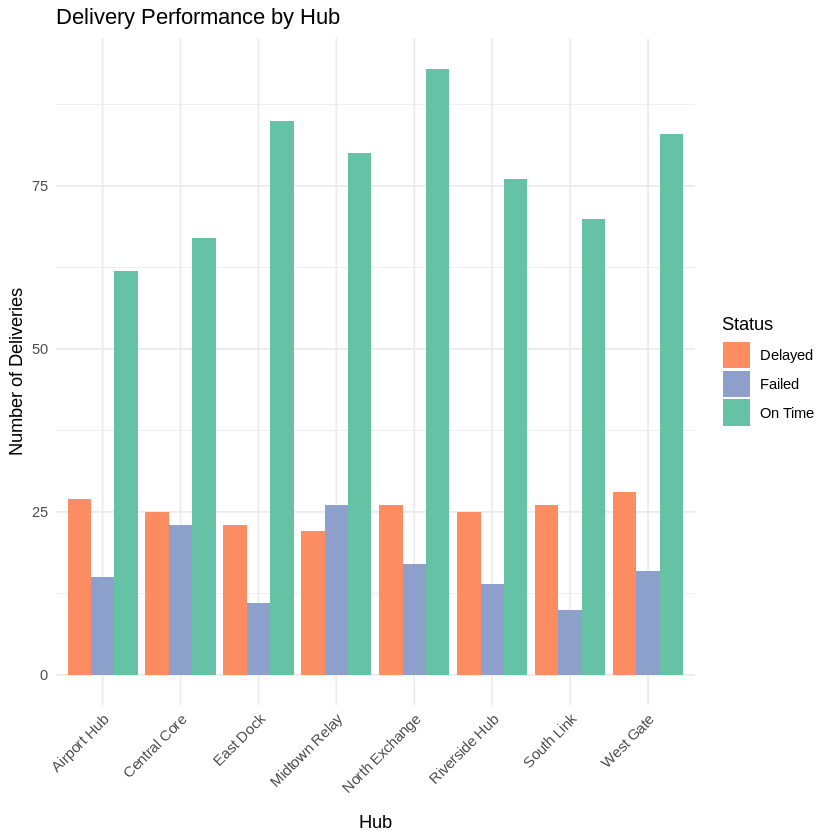

In [ ]:
# R Analysis 1 - Hub Performance Analysis
hub_performance$failure_rate <- hub_performance$failed_deliveries / hub_performance$total_deliveries
hub_performance$delay_rate <- hub_performance$delayed_deliveries / hub_performance$total_deliveries
hub_performance[order(-hub_performance$failure_rate), ]



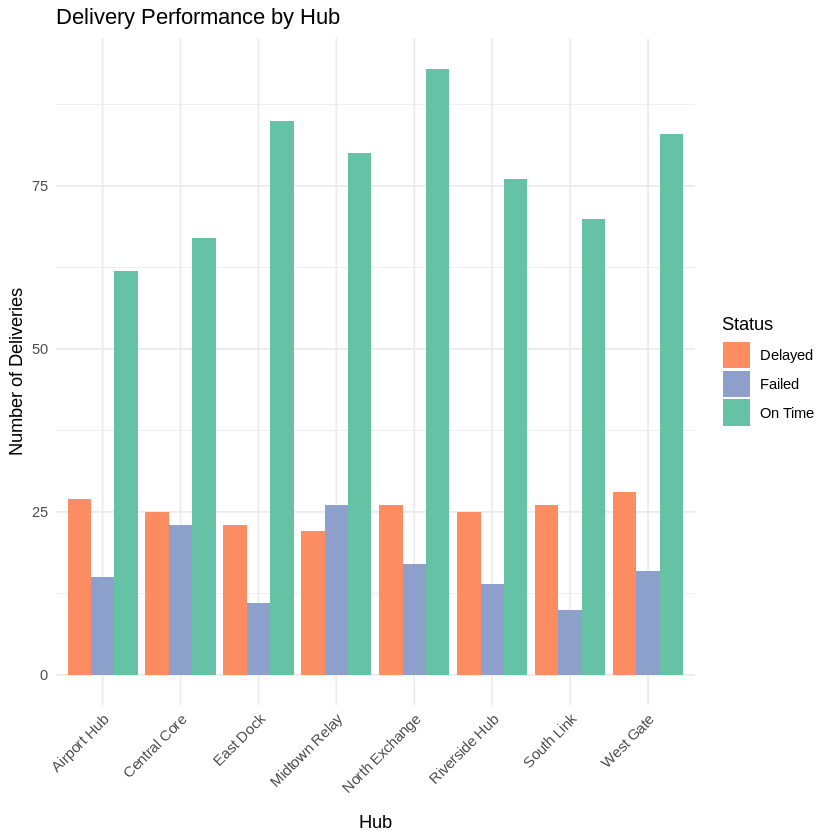

In [ ]:
# R Visualisation 1: Delivery outcome distribution by hub

hub_graph <- hub_performance %>%         #variable from SQL QUERY 1
  pivot_longer(
    cols = c(ontime_deliveries, delayed_deliveries, failed_deliveries),
    names_to = "delivery_status",
    values_to = "count"
  )

ggplot(hub_long, aes(x = hub_name, y = count, fill = status)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Delivery Performance by Hub",
    x = "Hub",
    y = "Number of Deliveries",
    fill = "Status"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_fill_manual(values = c("On Time" = "#66c2a5", "Delayed" = "#fc8d62", "Failed" = "#8da0cb"))

In [ ]:
# R Analysis 2 - Complaint and Service Type Analysis
aggregate(complaint_count ~ service_type, complaint_analysis, sum)
aggregate(total_compensation ~ service_type, complaint_analysis, sum)

service_type,complaint_count
<chr>,<int>
Business,39
Medical,37
Parcel,77
Passenger,84
Retail,83


service_type,total_compensation
<chr>,<dbl>
Business,810.86
Medical,740.01
Parcel,1463.65
Passenger,1657.53
Retail,1486.14


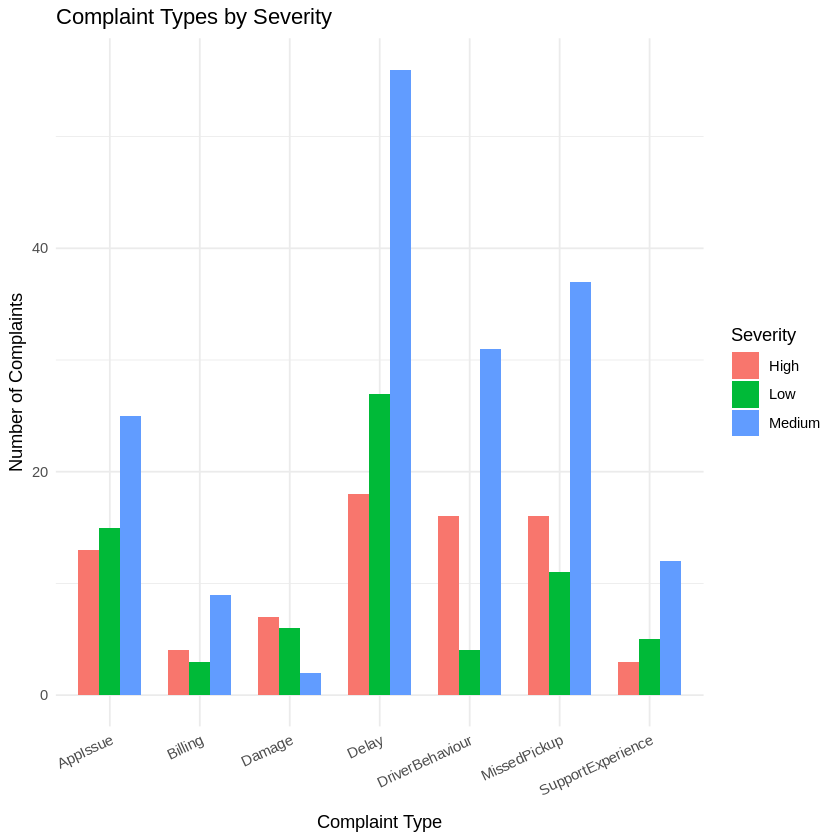

In [ ]:
# R Visualisation 2 — Complaint Type Volume Coloured by Severity
complaint_summary <- complaints %>%
  group_by(complaint_type, severity) %>%
  summarise(count = n(), .groups = "drop")

ggplot(
  complaint_summary,
  aes(x = complaint_type, y = count, fill = severity)
) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  labs(
    title = "Complaint Types by Severity",
    x = "Complaint Type",
    y = "Number of Complaints",
    fill = "Severity"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 25, hjust = 1)
  )

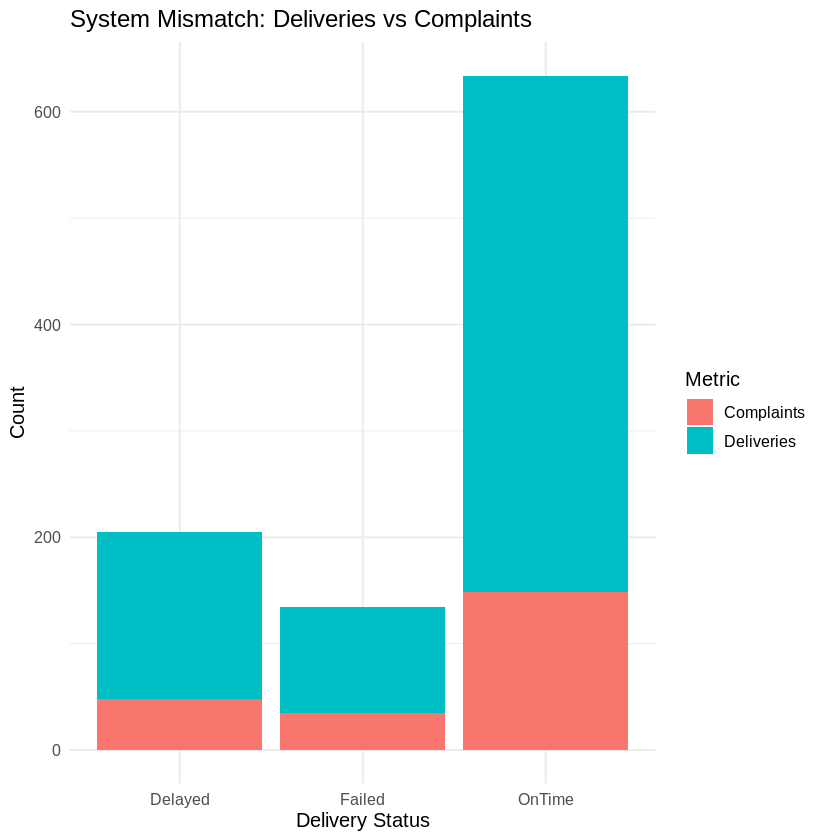

In [ ]:
mismatch_data$issue_rate <- mismatch_data$total_complaints / mismatch_data$total_deliveries

# R Visualization 3: System Mismatch Between Delivery Status and Customer Complaints
ggplot(mismatch_data,
       aes(x = delivery_status)) +

  geom_bar(aes(y = total_deliveries, fill = "Deliveries"),
           stat = "identity", position = "dodge") +

  geom_bar(aes(y = total_complaints, fill = "Complaints"),
           stat = "identity", position = "dodge") +

  labs(
    title = "System Mismatch: Deliveries vs Complaints",
    x = "Delivery Status",
    y = "Count",
    fill = "Metric"
  ) +

  theme_minimal(base_size = 12)

In [ ]:
# R Analysis 4 - Route Override Analysis
override_analysis$override_rate <- override_analysis$avg_overrides
aggregate(avg_overrides ~ employment_type, override_analysis, mean)
aggregate(avg_overrides ~ hub_name, override_analysis, mean)

employment_type,avg_overrides
<chr>,<dbl>
Contract,0.9190283
FullTime,1.0176520
PartTime,0.8661911


hub_name,avg_overrides
<chr>,<dbl>
Airport Hub,0.9000000
Central Core,0.9166097
East Dock,0.9974747
Midtown Relay,0.9614245
North Exchange,0.9755493
Riverside Hub,1.0307692
South Link,0.7825397
West Gate,0.9099567


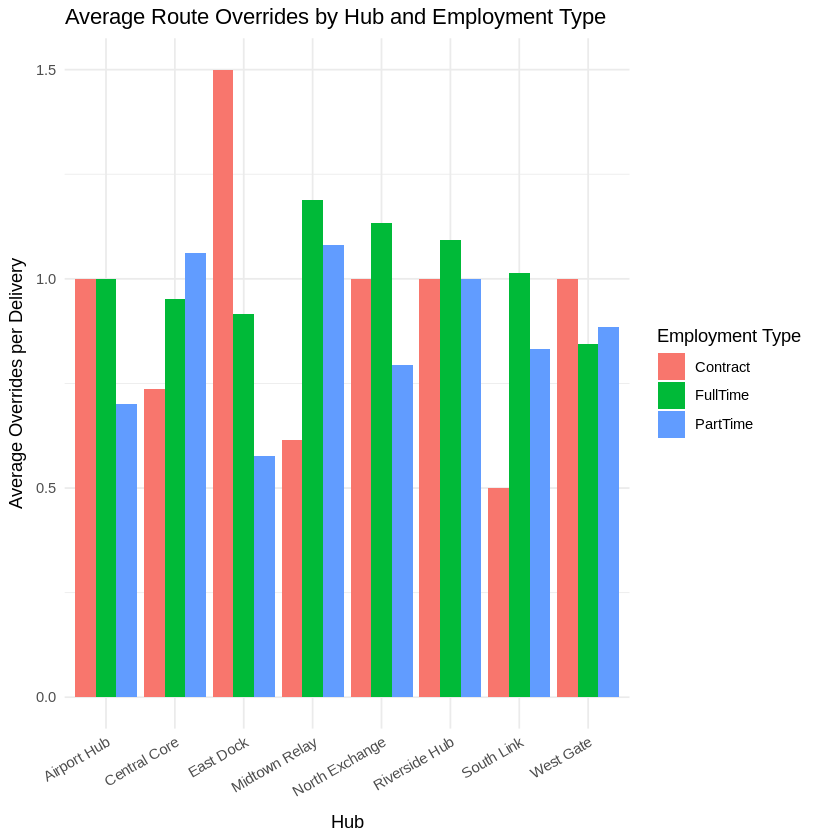

In [ ]:
# R Visualisation 4 — Average Route override by hubs and empoyment type

ggplot(override_analysis,
       aes(x = hub_name,
           y = avg_overrides,
           fill = employment_type)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Average Route Overrides by Hub and Employment Type",
    x = "Hub",
    y = "Average Overrides per Delivery",
    fill = "Employment Type"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

vehicle_type,incident_rate
<chr>,<dbl>
CargoVan,0.2669797
Diesel,0.3263052
EV,0.2956211
Hybrid,0.2745500


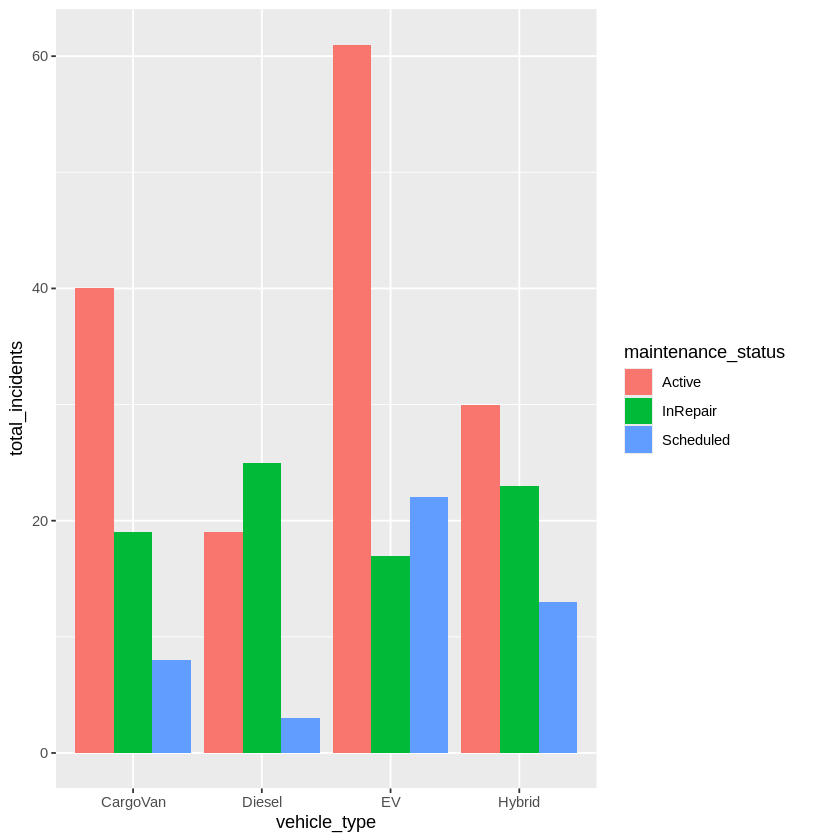

In [ ]:
# R analysis 5 — Incidents by Vehicle Type and Maintenance Status

vehicle_maintenance_analysis$incident_rate <-
  vehicle_maintenance_analysis$total_incidents /
  vehicle_maintenance_analysis$total_deliveries

aggregate(incident_rate ~ vehicle_type, vehicle_maintenance_analysis, mean)


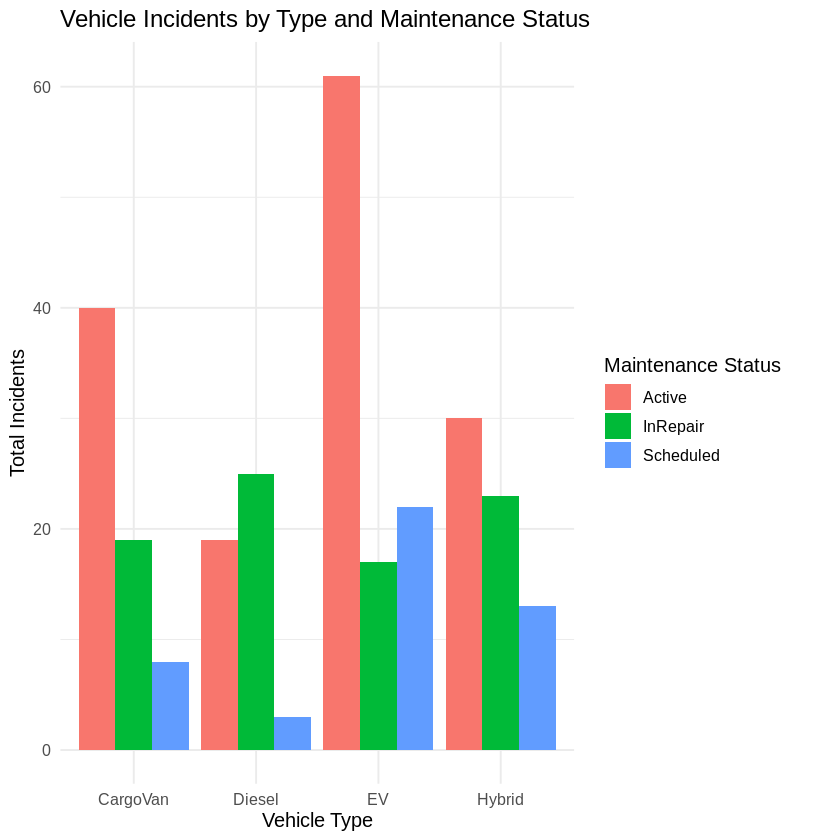

In [ ]:
# R Visualisation 5 — Incidents by Vehicle Type and Maintenance Status
ggplot(
  vehicle_maintenance_analysis,          #Variable from SQL QUERY 5
  aes(x = vehicle_type,
      y = total_incidents,
      fill = maintenance_status)
) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Vehicle Incidents by Type and Maintenance Status",
    x = "Vehicle Type",
    y = "Total Incidents",
    fill = "Maintenance Status"
  ) +
  theme_minimal(base_size = 12)

In [ ]:
# R Analysis 6 - Profitability Analysis
profitability$is_loss <- profitability$margin_pct < 0

aggregate(margin_pct ~ pickup_zone, profitability, mean)

profitability[order(profitability$margin_pct), ]



pickup_zone,margin_pct
<chr>,<dbl>
AIRPORT,82.42
CENTRAL,86.16
CTR,85.86
EAST,85.68
NORTH,86.08
RIVERSIDE,86.34
SOUTH,86.28
WEST,85.60


,service_type,pickup_zone,order_count,total_revenue,total_fuel_cost,gross_margin,avg_order_value,avg_fuel_cost,margin_pct,avg_route_km,is_loss
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,Business,AIRPORT,13,1081.84,244.10,837.74,83.22,18.78,77.4,30.6,FALSE
2,Medical,CTR,2,107.85,22.27,85.58,53.92,11.13,79.4,12.1,FALSE
3,Retail,AIRPORT,29,2687.13,519.15,2167.98,92.66,17.90,80.7,28.5,FALSE
4,Business,WEST,12,856.36,158.61,697.75,71.36,13.22,81.5,14.7,FALSE
5,Passenger,CENTRAL,34,2497.80,431.74,2066.06,73.46,12.70,82.7,11.5,FALSE
6,Medical,EAST,19,1428.19,245.51,1182.68,75.17,12.92,82.8,12.6,FALSE
7,Medical,NORTH,18,1300.36,222.47,1077.89,72.24,12.36,82.9,11.1,FALSE
8,Parcel,RIVERSIDE,28,2007.65,338.88,1668.77,71.70,12.10,83.1,13.4,FALSE
9,Retail,CTR,22,1728.18,292.25,1435.93,78.55,13.28,83.1,12.5,FALSE


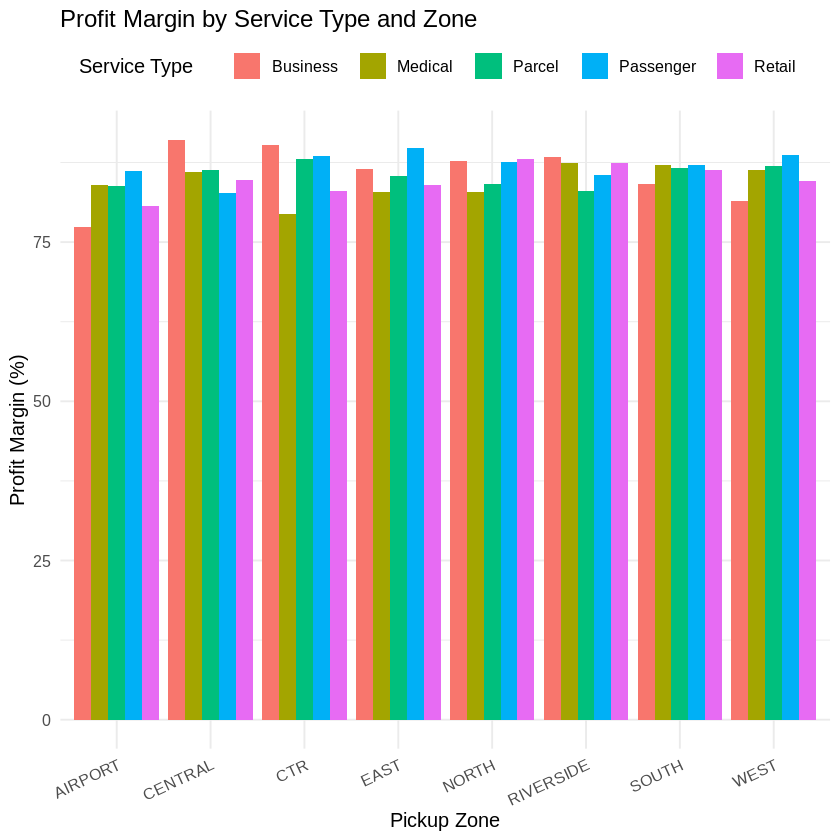

In [ ]:
# R Visualisation 6 — Average Gross Margin by Service Type and Priority

ggplot(profitability,
       aes(x = pickup_zone,
           y = margin_pct,
           fill = service_type)) +

  geom_bar(stat = "identity", position = "dodge") +

  labs(
    title = "Profit Margin by Service Type and Zone",
    x = "Pickup Zone",
    y = "Profit Margin (%)",
    fill = "Service Type"
  ) +

  theme_minimal(base_size = 12) +

  theme(
    axis.text.x = element_text(angle = 25, hjust = 1),
    legend.position = "top"
  )